# Negative pulse simulations (single porosity, two-component model)

This notebook simulates negative tracer pulses using the calibrated two-component model from `two_components/outputs/phase_exploitation/overall_best_refined_solution.csv`.

A negative pulse is created by injecting clean water (`inj_concs = [0, C0]`) into a system at background concentration `C0`, then returning to background. The breakthrough response dips below `C0` and recovers.

For each scenario the injection volume is varied across `V_inj = [600, 1800, 3000, 4500] bbl`. With injection rate `q_inj = 10 bbl/min`, the corresponding injection durations are `t_inj = V_inj / q_inj`:

- 600 bbl  -> 1.0 hr
- 1800 bbl -> 3.0 hr
- 3000 bbl -> 5.0 hr
- 4500 bbl -> 7.5 hr

Absolute concentration plotted in each figure:

`Ceq_R(t) = fr1 * (C1(t) - C0) + fr2 * (C2(t) - C0)`

`Ceq(t)   = Ceq_R(t) + C0`

Four scenarios are explored:

- Set 1: `C0 = 11 mg/L`, `R_f = 1.5`
- Set 2: `C0 = 11 mg/L`, `R_f = 3.5`
- Set 3: `C0 = 18 mg/L`, `R_f = 1.5`
- Set 4: `C0 = 18 mg/L`, `R_f = 3.5`

## 1) Imports

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 2) Read calibrated parameters

In [2]:
repo_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(repo_root))

from reactive_transport.simulation_options_2 import simulateDualPorosity

best_csv = repo_root / "two_components/outputs/phase_exploitation/overall_best_refined_solution.csv"
best_df = pd.read_csv(best_csv)

best_row = best_df.loc[best_df["best_J"].idxmin()]

mrt1_best = float(best_row["best_MRT1"])
mrt2_best = float(best_row["best_MRT2"])
pe1_best = float(best_row["best_Pe1"])
pe2_best = float(best_row["best_Pe2"])
fr1_best = float(best_row["best_fr1"])
fr2_best = float(best_row["best_fr2"])

best_df.head()

,basin_id,ref_run_idx,seed,best_MRT1,best_MRT2,best_Pe1,best_Pe2,best_fr1,best_fr2,best_J,nit,nfev,success,message
0,19,2,202,11.475848,48.819593,15.32661,2.034558,0.265815,0.671666,0.030909,59,5387,True,Optimization terminated successfully.


## 3) Define single-run negative-pulse model

In [3]:
def _v_tag(v_bbl):
    return f"{int(round(v_bbl))}"


def modelRELAP_negative_pulse(
    t,
    mrt,
    pec,
    fracture_retardation,
    bckgrnd_conc,
    inj_duration_hr,
):
    inj_concs = np.array([0.0, bckgrnd_conc], dtype=float)
    inj_durs = np.cumsum(np.array([inj_duration_hr], dtype=float))
    dpParam = 0.0
    matrix_retardation = 1.0
    recRatio = 0.0
    wsCoef = 0.0

    return np.asarray(
        simulateDualPorosity(
            mrt,
            pec,
            fracture_retardation,
            t,
            bckgrnd_conc,
            inj_concs,
            inj_durs,
            dpParam,
            matrix_retardation,
            recRatio=recRatio,
            wsCoef=wsCoef,
            delay_time=0,
        ),
        dtype=float,
    )

## 4) Set 1: `C0 = 11 mg/L`, `R_f = 1.5`

In [4]:
background_set1 = 11.0
fracture_retardation_set1 = 1.5
injection_volumes_bbl_set1 = [600.0, 1800.0, 3000.0, 4500.0]
q_inj_bbl_min = 10.0
t_plot_set1 = np.linspace(0.1, 130, 50)
results_set1 = {}

for v_bbl in injection_volumes_bbl_set1:
    inj_duration_hr = v_bbl / q_inj_bbl_min / 60.0

    c1_100 = modelRELAP_negative_pulse(
        t_plot_set1,
        mrt1_best,
        pe1_best,
        fracture_retardation_set1,
        background_set1,
        inj_duration_hr,
    )
    c2_100 = modelRELAP_negative_pulse(
        t_plot_set1,
        mrt2_best,
        pe2_best,
        fracture_retardation_set1,
        background_set1,
        inj_duration_hr,
    )

    c1_rel = c1_100 - background_set1
    c2_rel = c2_100 - background_set1
    c_eq_rel = fr1_best * c1_rel + fr2_best * c2_rel
    c_eq = c_eq_rel + background_set1

    results_set1[v_bbl] = {
        "inj_duration_hr": inj_duration_hr,
        "C_eq": c_eq,
    }

results_set1[600.0]["C_eq"][:5]

array([11.        , 10.99999607, 10.99526438, 10.93505244, 10.80728922])

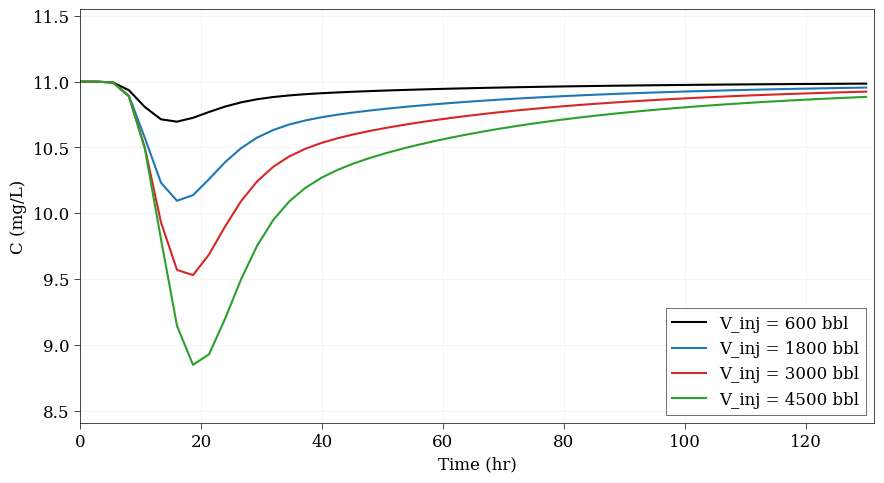

In [5]:
_pt = 1.5
_pt_hair = 0.5
font_size = 12
_grid_gray = "#F2F2F2"

line_colors_volumes = {
    600.0: "black",
    1800.0: "#1f77b4",
    3000.0: "#d62728",
    4500.0: "#2ca02c",
}

with plt.rc_context(
    {
        "font.family": "serif",
        "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
        "font.size": font_size,
        "axes.labelsize": font_size,
        "xtick.labelsize": font_size,
        "ytick.labelsize": font_size,
        "legend.fontsize": font_size,
        "text.color": "black",
        "axes.labelcolor": "black",
        "axes.edgecolor": "black",
        "xtick.color": "black",
        "ytick.color": "black",
        "xtick.direction": "out",
        "ytick.direction": "out",
        "legend.facecolor": "white",
        "legend.edgecolor": "black",
        "pdf.fonttype": 42,
    }
):
    fig, ax = plt.subplots(figsize=(9, 5), facecolor="white")
    ax.set_facecolor("white")

    ax.set_axisbelow(True)
    ax.grid(True, which="major", linewidth=_pt_hair, color=_grid_gray, linestyle="-")

    for v_bbl in injection_volumes_bbl_set1:
        ax.plot(
            t_plot_set1,
            results_set1[v_bbl]["C_eq"],
            color=line_colors_volumes[v_bbl],
            linewidth=_pt,
            label=f"V_inj = {int(v_bbl)} bbl",
        )

    ax.set_xlabel("Time (hr)")
    ax.set_ylabel("C (mg/L)")

    for side in ax.spines:
        ax.spines[side].set_visible(True)
        ax.spines[side].set_linewidth(_pt_hair)
        ax.spines[side].set_color("black")

    ax.tick_params(
        axis="both",
        which="major",
        direction="out",
        length=4,
        width=_pt_hair,
        colors="black",
        top=False,
        right=False,
    )

    y_min = min(np.min(results_set1[v]["C_eq"]) for v in injection_volumes_bbl_set1)
    ax.set_xlim(0, float(np.max(t_plot_set1)) * 1.01)
    ax.set_ylim(max(0.0, float(y_min) * 0.95), float(background_set1) * 1.05)

    leg = ax.legend(loc="lower right", frameon=True, facecolor="white", edgecolor="black", fancybox=False)
    leg.get_frame().set_linewidth(_pt_hair)
    leg.get_frame().set_edgecolor("black")

    fig.tight_layout()
    fig.patch.set_linewidth(0)
    fig.patch.set_edgecolor("none")

    # fig.savefig(
    #     "../Figures/negative_pulse_c0_11_rf_1p5.pdf",
    #     facecolor="white",
    #     edgecolor="none",
    #     bbox_inches="tight",
    #     pad_inches=0.25,
    # )

    plt.show()

In [6]:
tabular_results_dir = repo_root / "tabular_results"
tabular_results_dir.mkdir(parents=True, exist_ok=True)

df_set1 = pd.DataFrame({"time_hr": t_plot_set1})

for v_bbl in injection_volumes_bbl_set1:
    df_set1[f"C_eq_Vinj_{_v_tag(v_bbl)}_bbl_mgL"] = results_set1[v_bbl]["C_eq"]

out_xlsx_set1 = tabular_results_dir / "negative_pulse_c0_11_rf_1p5.xlsx"
df_set1.to_excel(out_xlsx_set1, index=False)
out_xlsx_set1

PosixPath('/mnt/c/Users/mhesh/OneDrive - Texas Tech University/Texas Tech/Utah Forge Geothermal/Geothermics Paper/Code/tabular_results/negative_pulse_c0_11_rf_1p5.xlsx')

## 5) Set 2: `C0 = 11 mg/L`, `R_f = 3.5`

In [7]:
background_set2 = 11.0
fracture_retardation_set2 = 3.5
injection_volumes_bbl_set2 = [600.0, 1800.0, 3000.0, 4500.0]
q_inj_bbl_min = 10.0
t_plot_set2 = np.linspace(0.1, 130, 50)
results_set2 = {}

for v_bbl in injection_volumes_bbl_set2:
    inj_duration_hr = v_bbl / q_inj_bbl_min / 60.0

    c1_100 = modelRELAP_negative_pulse(
        t_plot_set2,
        mrt1_best,
        pe1_best,
        fracture_retardation_set2,
        background_set2,
        inj_duration_hr,
    )
    c2_100 = modelRELAP_negative_pulse(
        t_plot_set2,
        mrt2_best,
        pe2_best,
        fracture_retardation_set2,
        background_set2,
        inj_duration_hr,
    )

    c1_rel = c1_100 - background_set2
    c2_rel = c2_100 - background_set2
    c_eq_rel = fr1_best * c1_rel + fr2_best * c2_rel
    c_eq = c_eq_rel + background_set2

    results_set2[v_bbl] = {
        "inj_duration_hr": inj_duration_hr,
        "C_eq": c_eq,
    }

results_set2[600.0]["C_eq"][:5]

array([11.        , 11.        , 10.99999972, 10.99994438, 10.99920208])

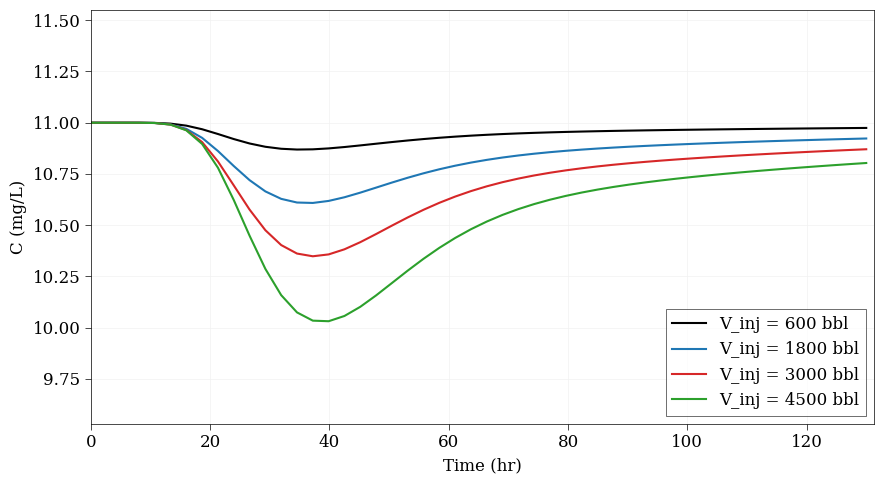

In [8]:
_pt = 1.5
_pt_hair = 0.5
font_size = 12
_grid_gray = "#F2F2F2"

line_colors_volumes = {
    600.0: "black",
    1800.0: "#1f77b4",
    3000.0: "#d62728",
    4500.0: "#2ca02c",
}

with plt.rc_context(
    {
        "font.family": "serif",
        "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
        "font.size": font_size,
        "axes.labelsize": font_size,
        "xtick.labelsize": font_size,
        "ytick.labelsize": font_size,
        "legend.fontsize": font_size,
        "text.color": "black",
        "axes.labelcolor": "black",
        "axes.edgecolor": "black",
        "xtick.color": "black",
        "ytick.color": "black",
        "xtick.direction": "out",
        "ytick.direction": "out",
        "legend.facecolor": "white",
        "legend.edgecolor": "black",
        "pdf.fonttype": 42,
    }
):
    fig, ax = plt.subplots(figsize=(9, 5), facecolor="white")
    ax.set_facecolor("white")

    ax.set_axisbelow(True)
    ax.grid(True, which="major", linewidth=_pt_hair, color=_grid_gray, linestyle="-")

    for v_bbl in injection_volumes_bbl_set2:
        ax.plot(
            t_plot_set2,
            results_set2[v_bbl]["C_eq"],
            color=line_colors_volumes[v_bbl],
            linewidth=_pt,
            label=f"V_inj = {int(v_bbl)} bbl",
        )

    ax.set_xlabel("Time (hr)")
    ax.set_ylabel("C (mg/L)")

    for side in ax.spines:
        ax.spines[side].set_visible(True)
        ax.spines[side].set_linewidth(_pt_hair)
        ax.spines[side].set_color("black")

    ax.tick_params(
        axis="both",
        which="major",
        direction="out",
        length=4,
        width=_pt_hair,
        colors="black",
        top=False,
        right=False,
    )

    y_min = min(np.min(results_set2[v]["C_eq"]) for v in injection_volumes_bbl_set2)
    ax.set_xlim(0, float(np.max(t_plot_set2)) * 1.01)
    ax.set_ylim(max(0.0, float(y_min) * 0.95), float(background_set2) * 1.05)

    leg = ax.legend(loc="lower right", frameon=True, facecolor="white", edgecolor="black", fancybox=False)
    leg.get_frame().set_linewidth(_pt_hair)
    leg.get_frame().set_edgecolor("black")

    fig.tight_layout()
    fig.patch.set_linewidth(0)
    fig.patch.set_edgecolor("none")

    # fig.savefig(
    #     "../Figures/negative_pulse_c0_11_rf_3p5.pdf",
    #     facecolor="white",
    #     edgecolor="none",
    #     bbox_inches="tight",
    #     pad_inches=0.25,
    # )

    plt.show()

In [9]:
tabular_results_dir = repo_root / "tabular_results"
tabular_results_dir.mkdir(parents=True, exist_ok=True)

df_set2 = pd.DataFrame({"time_hr": t_plot_set2})

for v_bbl in injection_volumes_bbl_set2:
    df_set2[f"C_eq_Vinj_{_v_tag(v_bbl)}_bbl_mgL"] = results_set2[v_bbl]["C_eq"]

out_xlsx_set2 = tabular_results_dir / "negative_pulse_c0_11_rf_3p5.xlsx"
df_set2.to_excel(out_xlsx_set2, index=False)
out_xlsx_set2

PosixPath('/mnt/c/Users/mhesh/OneDrive - Texas Tech University/Texas Tech/Utah Forge Geothermal/Geothermics Paper/Code/tabular_results/negative_pulse_c0_11_rf_3p5.xlsx')

## 6) Set 3: `C0 = 18 mg/L`, `R_f = 1.5`

In [10]:
background_set3 = 18.0
fracture_retardation_set3 = 1.5
injection_volumes_bbl_set3 = [600.0, 1800.0, 3000.0, 4500.0]
q_inj_bbl_min = 10.0
t_plot_set3 = np.linspace(0.1, 130, 50)
results_set3 = {}

for v_bbl in injection_volumes_bbl_set3:
    inj_duration_hr = v_bbl / q_inj_bbl_min / 60.0

    c1_100 = modelRELAP_negative_pulse(
        t_plot_set3,
        mrt1_best,
        pe1_best,
        fracture_retardation_set3,
        background_set3,
        inj_duration_hr,
    )
    c2_100 = modelRELAP_negative_pulse(
        t_plot_set3,
        mrt2_best,
        pe2_best,
        fracture_retardation_set3,
        background_set3,
        inj_duration_hr,
    )

    c1_rel = c1_100 - background_set3
    c2_rel = c2_100 - background_set3
    c_eq_rel = fr1_best * c1_rel + fr2_best * c2_rel
    c_eq = c_eq_rel + background_set3

    results_set3[v_bbl] = {
        "inj_duration_hr": inj_duration_hr,
        "C_eq": c_eq,
    }

results_set3[600.0]["C_eq"][:5]

array([18.        , 17.99999356, 17.9922508 , 17.89372217, 17.68465509])

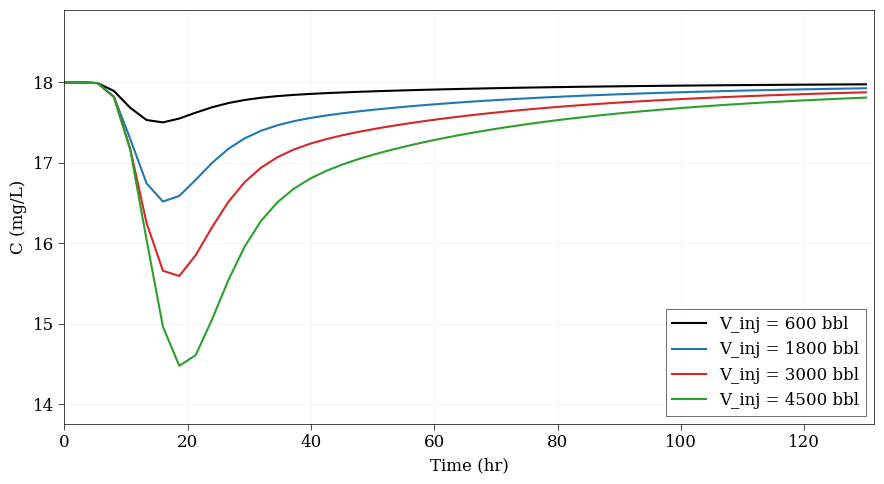

In [11]:
_pt = 1.5
_pt_hair = 0.5
font_size = 12
_grid_gray = "#F2F2F2"

line_colors_volumes = {
    600.0: "black",
    1800.0: "#1f77b4",
    3000.0: "#d62728",
    4500.0: "#2ca02c",
}

with plt.rc_context(
    {
        "font.family": "serif",
        "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
        "font.size": font_size,
        "axes.labelsize": font_size,
        "xtick.labelsize": font_size,
        "ytick.labelsize": font_size,
        "legend.fontsize": font_size,
        "text.color": "black",
        "axes.labelcolor": "black",
        "axes.edgecolor": "black",
        "xtick.color": "black",
        "ytick.color": "black",
        "xtick.direction": "out",
        "ytick.direction": "out",
        "legend.facecolor": "white",
        "legend.edgecolor": "black",
        "pdf.fonttype": 42,
    }
):
    fig, ax = plt.subplots(figsize=(9, 5), facecolor="white")
    ax.set_facecolor("white")

    ax.set_axisbelow(True)
    ax.grid(True, which="major", linewidth=_pt_hair, color=_grid_gray, linestyle="-")

    for v_bbl in injection_volumes_bbl_set3:
        ax.plot(
            t_plot_set3,
            results_set3[v_bbl]["C_eq"],
            color=line_colors_volumes[v_bbl],
            linewidth=_pt,
            label=f"V_inj = {int(v_bbl)} bbl",
        )

    ax.set_xlabel("Time (hr)")
    ax.set_ylabel("C (mg/L)")

    for side in ax.spines:
        ax.spines[side].set_visible(True)
        ax.spines[side].set_linewidth(_pt_hair)
        ax.spines[side].set_color("black")

    ax.tick_params(
        axis="both",
        which="major",
        direction="out",
        length=4,
        width=_pt_hair,
        colors="black",
        top=False,
        right=False,
    )

    y_min = min(np.min(results_set3[v]["C_eq"]) for v in injection_volumes_bbl_set3)
    ax.set_xlim(0, float(np.max(t_plot_set3)) * 1.01)
    ax.set_ylim(max(0.0, float(y_min) * 0.95), float(background_set3) * 1.05)

    leg = ax.legend(loc="lower right", frameon=True, facecolor="white", edgecolor="black", fancybox=False)
    leg.get_frame().set_linewidth(_pt_hair)
    leg.get_frame().set_edgecolor("black")

    fig.tight_layout()
    fig.patch.set_linewidth(0)
    fig.patch.set_edgecolor("none")

    # fig.savefig(
    #     "../Figures/negative_pulse_c0_18_rf_1p5.pdf",
    #     facecolor="white",
    #     edgecolor="none",
    #     bbox_inches="tight",
    #     pad_inches=0.25,
    # )

    plt.show()

In [12]:
tabular_results_dir = repo_root / "tabular_results"
tabular_results_dir.mkdir(parents=True, exist_ok=True)

df_set3 = pd.DataFrame({"time_hr": t_plot_set3})

for v_bbl in injection_volumes_bbl_set3:
    df_set3[f"C_eq_Vinj_{_v_tag(v_bbl)}_bbl_mgL"] = results_set3[v_bbl]["C_eq"]

out_xlsx_set3 = tabular_results_dir / "negative_pulse_c0_18_rf_1p5.xlsx"
df_set3.to_excel(out_xlsx_set3, index=False)
out_xlsx_set3

PosixPath('/mnt/c/Users/mhesh/OneDrive - Texas Tech University/Texas Tech/Utah Forge Geothermal/Geothermics Paper/Code/tabular_results/negative_pulse_c0_18_rf_1p5.xlsx')

## 7) Set 4: `C0 = 18 mg/L`, `R_f = 3.5`

In [13]:
background_set4 = 18.0
fracture_retardation_set4 = 3.5
injection_volumes_bbl_set4 = [600.0, 1800.0, 3000.0, 4500.0]
q_inj_bbl_min = 10.0
t_plot_set4 = np.linspace(0.1, 130, 50)
results_set4 = {}

for v_bbl in injection_volumes_bbl_set4:
    inj_duration_hr = v_bbl / q_inj_bbl_min / 60.0

    c1_100 = modelRELAP_negative_pulse(
        t_plot_set4,
        mrt1_best,
        pe1_best,
        fracture_retardation_set4,
        background_set4,
        inj_duration_hr,
    )
    c2_100 = modelRELAP_negative_pulse(
        t_plot_set4,
        mrt2_best,
        pe2_best,
        fracture_retardation_set4,
        background_set4,
        inj_duration_hr,
    )

    c1_rel = c1_100 - background_set4
    c2_rel = c2_100 - background_set4
    c_eq_rel = fr1_best * c1_rel + fr2_best * c2_rel
    c_eq = c_eq_rel + background_set4

    results_set4[v_bbl] = {
        "inj_duration_hr": inj_duration_hr,
        "C_eq": c_eq,
    }

results_set4[600.0]["C_eq"][:5]

array([18.        , 18.        , 17.99999955, 17.99990899, 17.99869432])

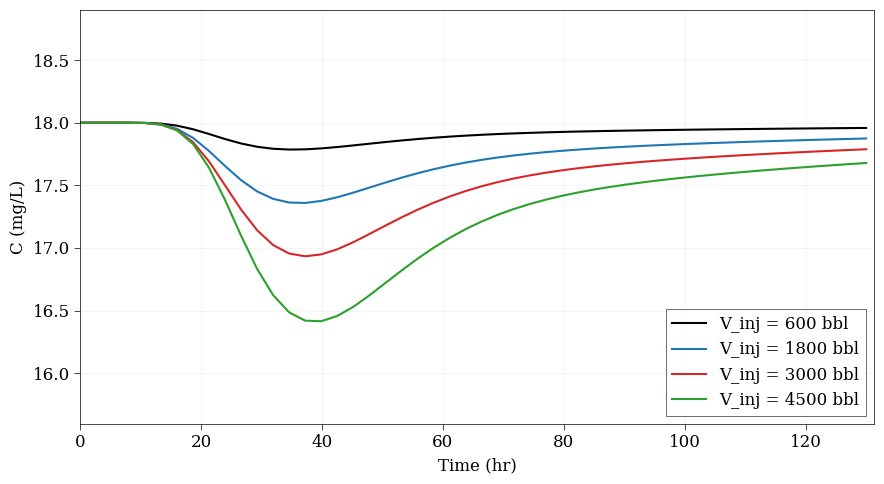

In [14]:
_pt = 1.5
_pt_hair = 0.5
font_size = 12
_grid_gray = "#F2F2F2"

line_colors_volumes = {
    600.0: "black",
    1800.0: "#1f77b4",
    3000.0: "#d62728",
    4500.0: "#2ca02c",
}

with plt.rc_context(
    {
        "font.family": "serif",
        "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
        "font.size": font_size,
        "axes.labelsize": font_size,
        "xtick.labelsize": font_size,
        "ytick.labelsize": font_size,
        "legend.fontsize": font_size,
        "text.color": "black",
        "axes.labelcolor": "black",
        "axes.edgecolor": "black",
        "xtick.color": "black",
        "ytick.color": "black",
        "xtick.direction": "out",
        "ytick.direction": "out",
        "legend.facecolor": "white",
        "legend.edgecolor": "black",
        "pdf.fonttype": 42,
    }
):
    fig, ax = plt.subplots(figsize=(9, 5), facecolor="white")
    ax.set_facecolor("white")

    ax.set_axisbelow(True)
    ax.grid(True, which="major", linewidth=_pt_hair, color=_grid_gray, linestyle="-")

    for v_bbl in injection_volumes_bbl_set4:
        ax.plot(
            t_plot_set4,
            results_set4[v_bbl]["C_eq"],
            color=line_colors_volumes[v_bbl],
            linewidth=_pt,
            label=f"V_inj = {int(v_bbl)} bbl",
        )

    ax.set_xlabel("Time (hr)")
    ax.set_ylabel("C (mg/L)")

    for side in ax.spines:
        ax.spines[side].set_visible(True)
        ax.spines[side].set_linewidth(_pt_hair)
        ax.spines[side].set_color("black")

    ax.tick_params(
        axis="both",
        which="major",
        direction="out",
        length=4,
        width=_pt_hair,
        colors="black",
        top=False,
        right=False,
    )

    y_min = min(np.min(results_set4[v]["C_eq"]) for v in injection_volumes_bbl_set4)
    ax.set_xlim(0, float(np.max(t_plot_set4)) * 1.01)
    ax.set_ylim(max(0.0, float(y_min) * 0.95), float(background_set4) * 1.05)

    leg = ax.legend(loc="lower right", frameon=True, facecolor="white", edgecolor="black", fancybox=False)
    leg.get_frame().set_linewidth(_pt_hair)
    leg.get_frame().set_edgecolor("black")

    fig.tight_layout()
    fig.patch.set_linewidth(0)
    fig.patch.set_edgecolor("none")

    # fig.savefig(
    #     "../Figures/negative_pulse_c0_18_rf_3p5.pdf",
    #     facecolor="white",
    #     edgecolor="none",
    #     bbox_inches="tight",
    #     pad_inches=0.25,
    # )

    plt.show()

In [15]:
tabular_results_dir = repo_root / "tabular_results"
tabular_results_dir.mkdir(parents=True, exist_ok=True)

df_set4 = pd.DataFrame({"time_hr": t_plot_set4})

for v_bbl in injection_volumes_bbl_set4:
    df_set4[f"C_eq_Vinj_{_v_tag(v_bbl)}_bbl_mgL"] = results_set4[v_bbl]["C_eq"]

out_xlsx_set4 = tabular_results_dir / "negative_pulse_c0_18_rf_3p5.xlsx"
df_set4.to_excel(out_xlsx_set4, index=False)
out_xlsx_set4

PosixPath('/mnt/c/Users/mhesh/OneDrive - Texas Tech University/Texas Tech/Utah Forge Geothermal/Geothermics Paper/Code/tabular_results/negative_pulse_c0_18_rf_3p5.xlsx')